In [1]:
import os
import joblib
import numpy
import matplotlib.pyplot as plt
import sys
sys.path.append(os.path.abspath("/content/drive/MyDrive/ML/udacity_introduction_to_ml/tools"))
from feature_format import featureFormat, targetFeatureSplit

In [2]:
from sklearn.cluster import KMeans

In [3]:
def Draw(pred, features, poi, mark_poi=False, name="image.png", f1_name="feature 1", f2_name="feature 2"):
    """ some plotting code designed to help you visualize your clusters """

    ### plot each cluster with a different color--add more colors for
    ### drawing more than five clusters
    colors = ["b", "c", "k", "m", "g"]
    for ii, pp in enumerate(pred):
        plt.scatter(features[ii][0], features[ii][1], color = colors[pred[ii]])

    ### if you like, place red stars over points that are POIs (just for funsies)
    if mark_poi:
        for ii, pp in enumerate(pred):
            if poi[ii]:
                plt.scatter(features[ii][0], features[ii][1], color="r", marker="*")
    plt.xlabel(f1_name)
    plt.ylabel(f2_name)
    plt.savefig(name)
    plt.show()

In [4]:
### load in the dict of dicts containing all the data on each person in the dataset
data_dict = joblib.load( open("/content/drive/MyDrive/ML/udacity_introduction_to_ml/final_project/final_project_dataset.pkl", "rb") )
### there's an outlier--remove it!
data_dict.pop("TOTAL", 0)

{'salary': 26704229,
 'to_messages': 'NaN',
 'deferral_payments': 32083396,
 'total_payments': 309886585,
 'loan_advances': 83925000,
 'bonus': 97343619,
 'email_address': 'NaN',
 'restricted_stock_deferred': -7576788,
 'deferred_income': -27992891,
 'total_stock_value': 434509511,
 'expenses': 5235198,
 'from_poi_to_this_person': 'NaN',
 'exercised_stock_options': 311764000,
 'from_messages': 'NaN',
 'other': 42667589,
 'from_this_person_to_poi': 'NaN',
 'poi': False,
 'long_term_incentive': 48521928,
 'shared_receipt_with_poi': 'NaN',
 'restricted_stock': 130322299,
 'director_fees': 1398517}

In [5]:
### the input features we want to use
### can be any key in the person-level dictionary (salary, director_fees, etc.)
feature_1 = "salary"
feature_2 = "exercised_stock_options"
poi  = "poi"
features_list = [poi, feature_1, feature_2]
data = featureFormat(data_dict, features_list )
poi, finance_features = targetFeatureSplit( data )

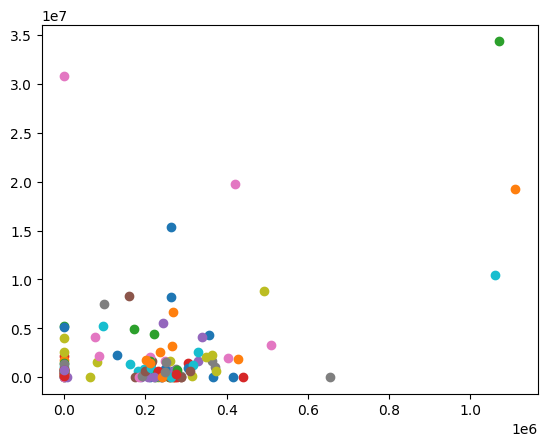

In [6]:
### in the "clustering with 3 features" part of the mini-project,
### you'll want to change this line to
### for f1, f2, _ in finance_features:
### (as it's currently written, the line below assumes 2 features)
for f1, f2 in finance_features:
    plt.scatter( f1, f2 )
plt.show()

In [7]:
### cluster here; create predictions of the cluster labels
### for the data and store them to a list called pred
from sklearn.cluster import KMeans
clf = KMeans(n_clusters=2)
pred = clf.fit_predict(finance_features)

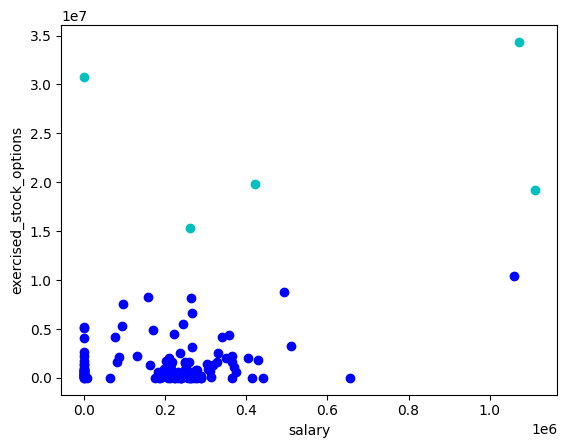

In [8]:
### rename the "name" parameter when you change the number of features
### so that the figure gets saved to a different file
try:
    Draw(pred, finance_features, poi, mark_poi=False, name="clusters_3_features_poi.pdf", f1_name=feature_1, f2_name=feature_2)
except NameError:
    print("No predictions object named pred found, no clusters to plot")

Add a third feature to features_list, “total_payments". Now rerun clustering, using 3 input features instead of 2 (obviously we can still only visualize the original 2 dimensions). Compare the plot with the clusterings to the one you obtained with 2 input features.

**Do any points switch clusters? How many?**

This new clustering, using 3 features, couldn’t have been guessed by eye--it was the k-means algorithm that identified it.

(You'll need to change the code that makes the scatterplot to accommodate 3 features instead of 2, see the comments in the starter code for instructions on how to do this.)

In [5]:
# I will add total_payments as a third feature here
feature_1 = "salary"
feature_2 = "exercised_stock_options"
feature_3 = "total_payments"
poi  = "poi"
features_list = [poi, feature_1, feature_2, feature_3]
data = featureFormat(data_dict, features_list )
poi, finance_features = targetFeatureSplit( data )

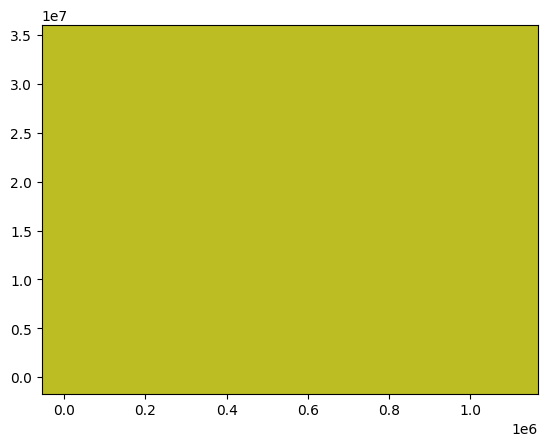

In [6]:
for f1, f2, _ in finance_features:
    plt.scatter( f1, f2, _ )
plt.show()

In [7]:
clf = KMeans(n_clusters=2)
pred = clf.fit_predict(finance_features)

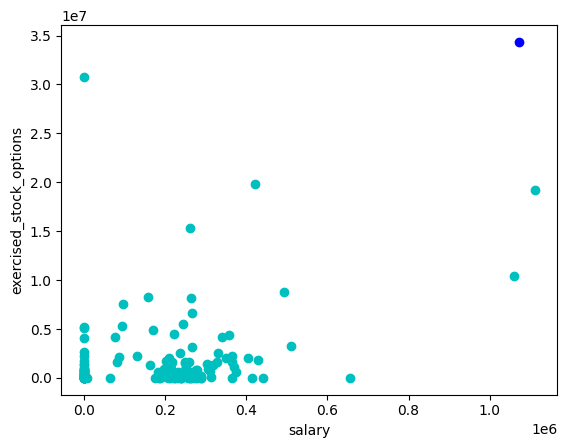

In [8]:
try:
    Draw(pred, finance_features, poi, mark_poi=False, name="clusters_with_3fs.pdf", f1_name=feature_1, f2_name=feature_2)
except NameError:
    print("No predictions object named pred found, no clusters to plot")

In the next lesson, we’ll talk about feature scaling. It’s a type of feature preprocessing that you should perform before some classification and regression tasks. Here’s a sneak preview that should call your attention to the general outline of what feature scaling does.

**What are the maximum and minimum values taken by the “exercised_stock_options” feature used in this example?**

(NB: if you look at finance_features, there are some "NaN" values that have been cleaned away and replaced with zeroes--so while those might look like the minima, it's a bit deceptive because they're more like points for which we don't have information, and just have to put in a number. So for this question, go back to data_dict and look for the maximum and minimum numbers that show up there, ignoring all the "NaN" entries.)

In [9]:
# I will do that task using pandas library
import pandas as pd
df = pd.DataFrame.from_dict(data_dict, orient='index')
df.head()

,salary,to_messages,deferral_payments,total_payments,loan_advances,bonus,email_address,restricted_stock_deferred,deferred_income,total_stock_value,...,from_poi_to_this_person,exercised_stock_options,from_messages,other,from_this_person_to_poi,poi,long_term_incentive,shared_receipt_with_poi,restricted_stock,director_fees
METTS MARK,365788,807,NaN,1061827,NaN,600000,mark.metts@enron.com,NaN,NaN,585062,...,38,NaN,29,1740,1,False,NaN,702,585062,NaN
BAXTER JOHN C,267102,NaN,1295738,5634343,NaN,1200000,NaN,NaN,-1386055,10623258,...,NaN,6680544,NaN,2660303,NaN,False,1586055,NaN,3942714,NaN
ELLIOTT STEVEN,170941,NaN,NaN,211725,NaN,350000,steven.elliott@enron.com,NaN,-400729,6678735,...,NaN,4890344,NaN,12961,NaN,False,NaN,NaN,1788391,NaN
CORDES WILLIAM R,NaN,764,NaN,NaN,NaN,NaN,bill.cordes@enron.com,NaN,NaN,1038185,...,10,651850,12,NaN,0,False,NaN,58,386335,NaN
HANNON KEVIN P,243293,1045,NaN,288682,NaN,1500000,kevin.hannon@enron.com,NaN,-3117011,6391065,...,32,5538001,32,11350,21,True,1617011,1035,853064,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, METTS MARK to GLISAN JR BEN F
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   salary                     145 non-null    object
 1   to_messages                145 non-null    object
 2   deferral_payments          145 non-null    object
 3   total_payments             145 non-null    object
 4   loan_advances              145 non-null    object
 5   bonus                      145 non-null    object
 6   email_address              145 non-null    object
 7   restricted_stock_deferred  145 non-null    object
 8   deferred_income            145 non-null    object
 9   total_stock_value          145 non-null    object
 10  expenses                   145 non-null    object
 11  from_poi_to_this_person    145 non-null    object
 12  exercised_stock_options    145 non-null    object
 13  from_messages              145 non-null    object

In [11]:
# change "NaN" into null values using numpy
df = df.replace(to_replace='NaN', value=numpy.nan)

/tmp/ipython-input-199219427.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(to_replace='NaN', value=numpy.nan)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, METTS MARK to GLISAN JR BEN F
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   salary                     94 non-null     float64
 1   to_messages                86 non-null     float64
 2   deferral_payments          38 non-null     float64
 3   total_payments             124 non-null    float64
 4   loan_advances              3 non-null      float64
 5   bonus                      81 non-null     float64
 6   email_address              111 non-null    object 
 7   restricted_stock_deferred  17 non-null     float64
 8   deferred_income            48 non-null     float64
 9   total_stock_value          125 non-null    float64
 10  expenses                   94 non-null     float64
 11  from_poi_to_this_person    86 non-null     float64
 12  exercised_stock_options    101 non-null    float64
 13  from_messages              86 non-

In [13]:
print("Max exercised_stock_options is", {df['exercised_stock_options'].max()})

Max exercised_stock_options is {34348384.0}


In [14]:
print("Min exercised_stock_options is", {df['exercised_stock_options'].min()})

Min exercised_stock_options is {3285.0}


**What are the maximum and minimum values taken by “salary”?**

(NB: same caveat as in the last quiz. If you look at finance_features, there are some "NaN" values that have been cleaned away and replaced with zeroes--so while those might look like the minima, it's a bit deceptive because they're more like points for which we don't have information, and just have to put in a number. So for this question, go back to data_dict and look for the maximum and minimum numbers that show up there, ignoring all the "NaN" entries.)

In [15]:
print("Max salary is", {df['salary'].max()})

Max salary is {1111258.0}


In [16]:
print("Min salary is", {df['salary'].min()})

Min salary is {477.0}
